### Settings

Declare project name. 

In [5]:
from ema_forecast_control.utils import path_utils, model_catalogue

project_name = 'v3_MRT3_every_day_latest_valid'
test_data_dir = path_utils.join_base_path('data/AI4U_sample3')

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']

inverted_items = [1, 2, 3, 4, 5, 7, 8, 10, 12]

initial_condition_version = 'trajectory'        # 'trajectory', 'unit vectors'

save_as = f'AI4U/network_{project_name}.png'

models = model_catalogue.ModelCatalogue(project_name)

alpha_level = 0.01 / (15 ** 2)

### Network calculation

In [3]:
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control.plrnn.plrnn_model import PLRNN
from ema_forecast_control.utils import path_utils
from ema_forecast_control.utils import network_utils
from ema_forecast_control._ai4u_utils.ai4u_utils import determine_model_class

networks = []
no_gamma_found = 0
for p, df in path_utils.zip_participants_data(test_data_dir):
    model_dirs = models.get_all_model_dirs(p)
    participant_networks = []
    for model_dir in model_dirs:            
        if model_dir is None:
            continue
        args = path_utils.load_args(model_dir)
        model_class = determine_model_class(args)
        model = model_class(args)
        model.init_from_model_path(model_dir)
        if isinstance(model, PLRNN):
            try:
                Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
            except FileNotFoundError:
                no_gamma_found += 1
                continue
            if initial_condition_version == 'trajectory':
                x = tc.tensor(df[labels].to_numpy()).float()
            elif initial_condition_version == 'unit vectors':
                x = tc.cat((tc.eye(len(labels)).float(), tc.zeros(len(labels)).float().unsqueeze(0)), 0)
            network = network_utils.get_network_matrix(model, x, Gamma=Gamma).nanmean(0)        # For PLRNN, take mean over the trajectory (Jacobians for linear sub-regions)
        else:
            network = network_utils.get_network_matrix(model)  
        participant_networks.append(network)
    if len(participant_networks) > 0:
        participant_networks = tc.stack(participant_networks, dim=0).mean(0)
        networks.append(participant_networks)

if no_gamma_found > 0:
    print(f'Found no Covariance Gamma for {no_gamma_found} models.')

### Network plot

No counterintuitive connections found.


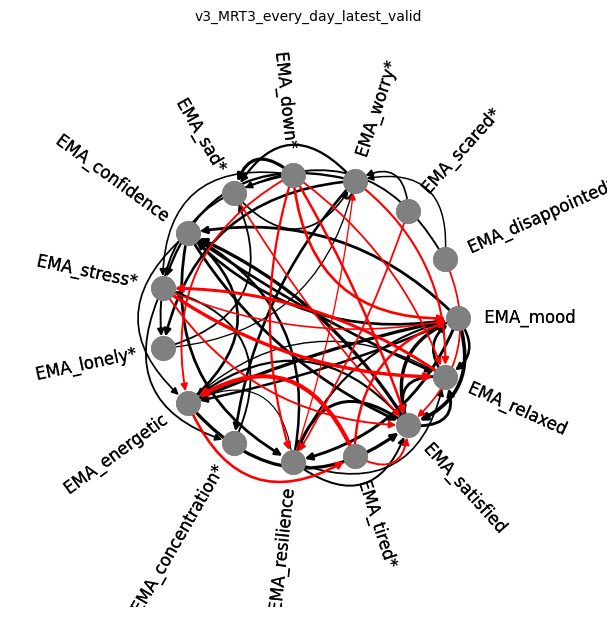

In [6]:
import os
from ema_forecast_control.plotting.plotting_styles import PaperStyle

if len(networks) > 0:
    with PaperStyle(settings={'axes.grid':False, 'axes.facecolor':'white'}):
        stacked_networks = tc.stack(networks, dim=0)
        network_utils.plot_network_graph(stacked_networks, node_labels=labels, inverted_items=inverted_items, title=project_name, alpha_level=alpha_level, fisher_transform=False, max_edge_number=None)
        if save_as is not None:
            path = path_utils.join_base_path('results', save_as)
            os.makedirs(os.path.dirname(path), exist_ok=True)
            plt.savefig(path, dpi=300)
        plt.show()

In [8]:
stacked_networks.std()

tensor(0.0517)